# QEC Dataset & Model Analysis
Stim+PyMatching trusted dataset(20K 샘플)과 학습 결과를 종합 점검한다.
- 데이터셋 신뢰도, 분포, mask 특성
- 학습 곡선 비교 (h16 vs h32)
- 양자화 검증 결과
- Logical error rate

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

workspace_root = Path('/home/user/Documents/박범도/2.2026 Capstone')
data_path = workspace_root / 'artifacts' / 'data' / 'synthetic_qec_dataset.npz'
manifest_path = workspace_root / 'artifacts' / 'reports' / 'dataset_manifest.json'

assert data_path.exists(), f'Missing dataset: {data_path}'
assert manifest_path.exists(), f'Missing manifest: {manifest_path}'

data = np.load(data_path, allow_pickle=True)
manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
trusted = manifest.get('trusted_sampling', {})

print('Dataset path:', data_path)
print('Manifest path:', manifest_path)
print('Trusted sampling enabled:', trusted.get('trusted_samples_only'))

Dataset path: /home/user/Documents/박범도/2.2026 Capstone/artifacts/data/synthetic_qec_dataset.npz
Manifest path: /home/user/Documents/박범도/2.2026 Capstone/artifacts/reports/dataset_manifest.json
Trusted sampling enabled: True


## 1. Dataset And Sampling Summary
데이터셋 key, shape, dtype와 trusted sampling 메타데이터를 먼저 확인한다.

In [2]:
summary_rows = []
for key in data.files:
    value = data[key]
    summary_rows.append({'key': key, 'shape': value.shape, 'dtype': str(value.dtype)})

summary_df = pd.DataFrame(summary_rows).sort_values('key').reset_index(drop=True)
trusted_df = pd.DataFrame([trusted])
display(summary_df)
display(trusted_df)

,key,shape,dtype
0,ambiguity,"(20000,)",int8
1,baseline_x_obs,"(20000,)",int8
2,baseline_z_obs,"(20000,)",int8
3,logical_x,"(20000,)",int8
4,logical_z,"(20000,)",int8
5,meta,"(1,)",object
6,selected_coords,"(8, 2)",float32
7,x_acceptance_rate,"(1,)",float32
8,x_features,"(20000, 24)",int8
9,x_masks,"(20000, 9)",int8


,num_samples,physical_error_rate,rounds,num_data_qubits,num_stabilizers,trusted_samples_only,x_acceptance_rate,z_acceptance_rate,x_total_sampled,z_total_sampled,mapping_trace
0,20000,0.02,3,9,8,True,0.893225,0.86995,40000,40000,"{'single_detector_supported_qubits': [0, 1, 2,..."


## 2. Logical Consistency Check
baseline observable과 logical observable이 실제로 완전히 일치하는지, acceptance rate는 어느 정도인지 확인한다.

,metric,value
0,x_path_baseline_obs_match,1.000000
1,z_path_baseline_obs_match,1.000000
2,x_path_acceptance_rate,0.893225
3,z_path_acceptance_rate,0.869950
4,x_path_logical_one_rate,0.208050
5,z_path_logical_one_rate,0.210350


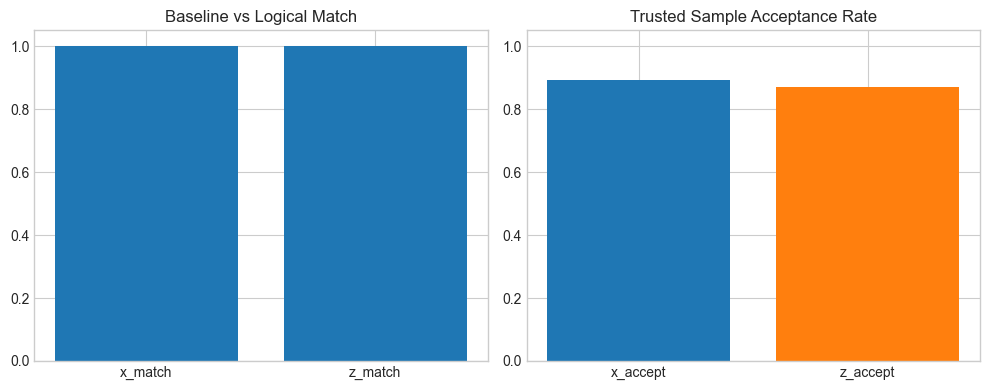

In [3]:
logical_compare_df = pd.DataFrame(
    {
        'metric': [
            'x_path_baseline_obs_match',
            'z_path_baseline_obs_match',
            'x_path_acceptance_rate',
            'z_path_acceptance_rate',
            'x_path_logical_one_rate',
            'z_path_logical_one_rate',
        ],
        'value': [
            float(np.mean(data['logical_x'] == data['baseline_x_obs'])),
            float(np.mean(data['logical_z'] == data['baseline_z_obs'])),
            float(data['x_acceptance_rate'][0]),
            float(data['z_acceptance_rate'][0]),
            float(np.mean(data['logical_x'])),
            float(np.mean(data['logical_z'])),
        ],
    }
)
display(logical_compare_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['x_match', 'z_match'], logical_compare_df.loc[:1, 'value'])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Baseline vs Logical Match')
axes[1].bar(['x_accept', 'z_accept'], logical_compare_df.loc[2:3, 'value'], color=['tab:blue', 'tab:orange'])
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Trusted Sample Acceptance Rate')
plt.tight_layout()
plt.show()

## 3. Feature And Mask Distribution
입력 detector feature 활성도와 출력 correction mask의 sparsity가 현재도 적절한지 본다.

## 2.5. Syndrome Dataset Structure
발표용으로 데이터 한 샘플이 어떤 구조를 가지는지 직관적으로 확인한다.
- 입력 feature 24비트는 3개 round의 detector history를 8개 detector씩 펼친 값이다.
- 출력 mask 9비트는 3×3 data qubit correction mask로 볼 수 있다.
- 아래 그림은 tensor shape 요약과 실제 샘플 예시를 함께 보여준다.

,tensor,stored_shape,interpreted_shape_per_sample,meaning
0,x_features,"(20000, 24)","(3 rounds, 8 detectors)",X syndrome detector history
1,z_features,"(20000, 24)","(3 rounds, 8 detectors)",Z syndrome detector history
2,x_masks,"(20000, 9)","(3, 3 data qubits)",X correction mask
3,z_masks,"(20000, 9)","(3, 3 data qubits)",Z correction mask


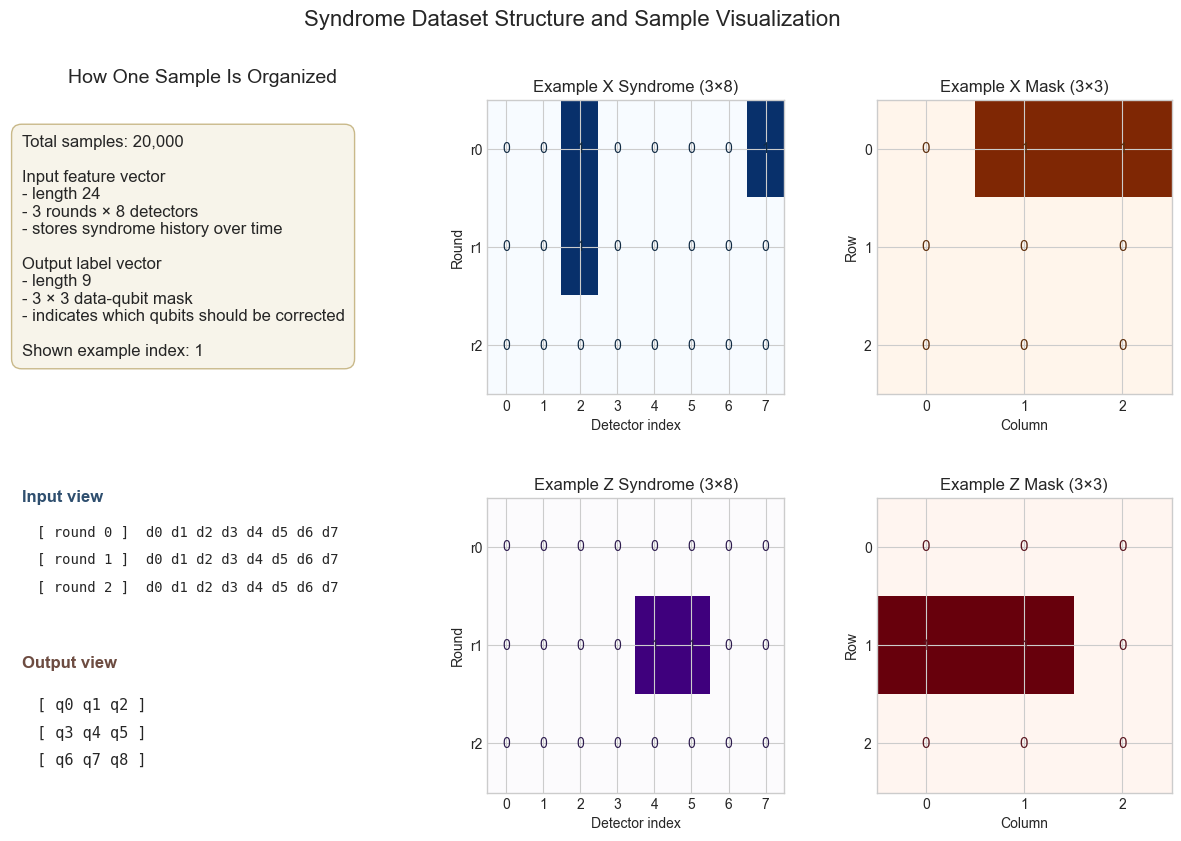

In [3]:
dataset_shape_df = pd.DataFrame(
    [
        {
            'tensor': 'x_features',
            'stored_shape': tuple(data['x_features'].shape),
            'interpreted_shape_per_sample': '(3 rounds, 8 detectors)',
            'meaning': 'X syndrome detector history',
        },
        {
            'tensor': 'z_features',
            'stored_shape': tuple(data['z_features'].shape),
            'interpreted_shape_per_sample': '(3 rounds, 8 detectors)',
            'meaning': 'Z syndrome detector history',
        },
        {
            'tensor': 'x_masks',
            'stored_shape': tuple(data['x_masks'].shape),
            'interpreted_shape_per_sample': '(3, 3 data qubits)',
            'meaning': 'X correction mask',
        },
        {
            'tensor': 'z_masks',
            'stored_shape': tuple(data['z_masks'].shape),
            'interpreted_shape_per_sample': '(3, 3 data qubits)',
            'meaning': 'Z correction mask',
        },
    ]
)

display(dataset_shape_df)

rounds = int(manifest['dataset']['rounds'])
num_detectors = int(manifest['dataset']['num_stabilizers'])

sample_idx = int(np.argmax(data['x_masks'].sum(axis=1) + data['z_masks'].sum(axis=1)))
x_sample = data['x_features'][sample_idx].reshape(rounds, num_detectors)
z_sample = data['z_features'][sample_idx].reshape(rounds, num_detectors)
x_mask_sample = data['x_masks'][sample_idx].reshape(3, 3)
z_mask_sample = data['z_masks'][sample_idx].reshape(3, 3)

fig = plt.figure(figsize=(15, 9))
grid = fig.add_gridspec(2, 3, width_ratios=[1.3, 1, 1], hspace=0.35, wspace=0.28)

ax0 = fig.add_subplot(grid[:, 0])
ax0.axis('off')
ax0.set_title('How One Sample Is Organized', fontsize=14, pad=12)

structure_text = (
    f'Total samples: {len(data["x_features"]):,}\n\n'
    'Input feature vector\n'
    '- length 24\n'
    '- 3 rounds × 8 detectors\n'
    '- stores syndrome history over time\n\n'
    'Output label vector\n'
    '- length 9\n'
    '- 3 × 3 data-qubit mask\n'
    '- indicates which qubits should be corrected\n\n'
    f'Shown example index: {sample_idx}'
)

ax0.text(
    0.03,
    0.95,
    structure_text,
    va='top',
    ha='left',
    fontsize=12,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f7f4ea', edgecolor='#c9b98a'),
)

ax0.text(0.03, 0.42, 'Input view', fontsize=12, weight='bold', color='#2f4f6f')
ax0.text(0.07, 0.37, '[ round 0 ]  d0 d1 d2 d3 d4 d5 d6 d7', fontsize=10, family='monospace')
ax0.text(0.07, 0.33, '[ round 1 ]  d0 d1 d2 d3 d4 d5 d6 d7', fontsize=10, family='monospace')
ax0.text(0.07, 0.29, '[ round 2 ]  d0 d1 d2 d3 d4 d5 d6 d7', fontsize=10, family='monospace')

ax0.text(0.03, 0.18, 'Output view', fontsize=12, weight='bold', color='#6d4c41')
ax0.text(0.07, 0.12, '[ q0 q1 q2 ]', fontsize=11, family='monospace')
ax0.text(0.07, 0.08, '[ q3 q4 q5 ]', fontsize=11, family='monospace')
ax0.text(0.07, 0.04, '[ q6 q7 q8 ]', fontsize=11, family='monospace')

ax1 = fig.add_subplot(grid[0, 1])
ax1.imshow(x_sample, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax1.set_title('Example X Syndrome (3×8)')
ax1.set_xlabel('Detector index')
ax1.set_ylabel('Round')
ax1.set_xticks(range(num_detectors))
ax1.set_yticks(range(rounds))
ax1.set_yticklabels([f'r{i}' for i in range(rounds)])
for row in range(rounds):
    for col in range(num_detectors):
        ax1.text(col, row, int(x_sample[row, col]), ha='center', va='center', color='#102a43', fontsize=10)

ax2 = fig.add_subplot(grid[0, 2])
ax2.imshow(x_mask_sample, cmap='Oranges', vmin=0, vmax=1)
ax2.set_title('Example X Mask (3×3)')
ax2.set_xlabel('Column')
ax2.set_ylabel('Row')
ax2.set_xticks(range(3))
ax2.set_yticks(range(3))
for row in range(3):
    for col in range(3):
        ax2.text(col, row, int(x_mask_sample[row, col]), ha='center', va='center', color='#5d2e0c', fontsize=11)

ax3 = fig.add_subplot(grid[1, 1])
ax3.imshow(z_sample, cmap='Purples', aspect='auto', vmin=0, vmax=1)
ax3.set_title('Example Z Syndrome (3×8)')
ax3.set_xlabel('Detector index')
ax3.set_ylabel('Round')
ax3.set_xticks(range(num_detectors))
ax3.set_yticks(range(rounds))
ax3.set_yticklabels([f'r{i}' for i in range(rounds)])
for row in range(rounds):
    for col in range(num_detectors):
        ax3.text(col, row, int(z_sample[row, col]), ha='center', va='center', color='#2d1b4e', fontsize=10)

ax4 = fig.add_subplot(grid[1, 2])
ax4.imshow(z_mask_sample, cmap='Reds', vmin=0, vmax=1)
ax4.set_title('Example Z Mask (3×3)')
ax4.set_xlabel('Column')
ax4.set_ylabel('Row')
ax4.set_xticks(range(3))
ax4.set_yticks(range(3))
for row in range(3):
    for col in range(3):
        ax4.text(col, row, int(z_mask_sample[row, col]), ha='center', va='center', color='#5a1620', fontsize=11)

fig.suptitle('Syndrome Dataset Structure and Sample Visualization', fontsize=16, y=0.98)
plt.show()

,feature,x_rate,z_rate
0,r0_d0,0.13065,0.12560
1,r0_d1,0.15945,0.15595
2,r0_d2,0.18740,0.19025
3,r0_d3,0.07955,0.08300
4,r0_d4,0.08535,0.08595
5,r0_d5,0.19365,0.19745
6,r0_d6,0.15445,0.15460
7,r0_d7,0.12785,0.12775
8,r1_d0,0.12470,0.12495
9,r1_d1,0.15750,0.15335


,mask_bit,x_mask_rate,z_mask_rate
0,q0,0.14440,0.14250
1,q1,0.30640,0.30165
2,q2,0.09770,0.08720
3,q3,0.16610,0.16290
4,q4,0.22350,0.22115
5,q5,0.14890,0.15385
6,q6,0.02060,0.02095
7,q7,0.07995,0.08255
8,q8,0.02315,0.02060


,path,mean_hamming_weight,zero_mask_ratio
0,x,1.21070,0.11085
1,z,1.19335,0.11300


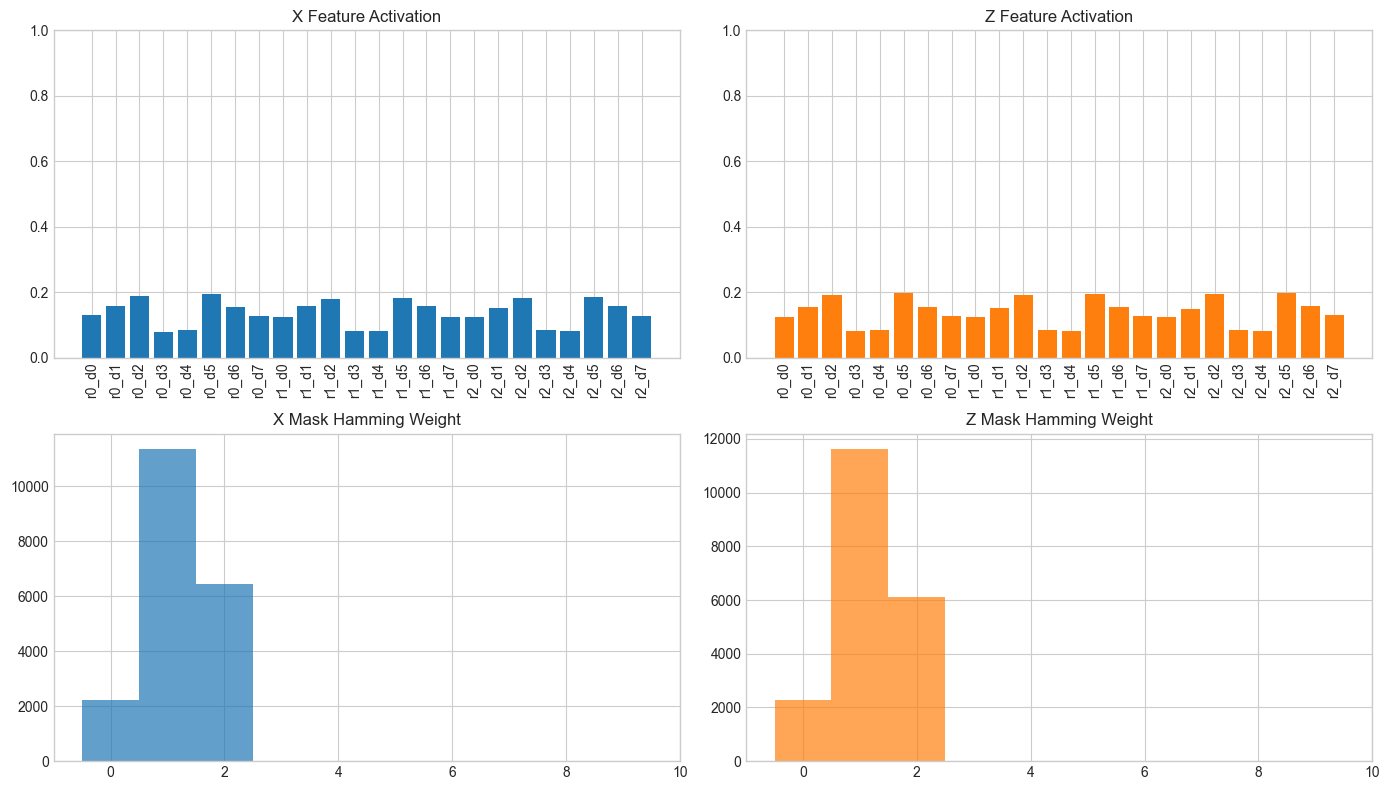

In [4]:
rounds = manifest['dataset']['rounds']
num_detectors = manifest['dataset']['num_stabilizers']
feature_labels = [f'r{r}_d{d}' for r in range(rounds) for d in range(num_detectors)]
mask_labels = [f'q{i}' for i in range(data['x_masks'].shape[1])]

x_features = data['x_features']
z_features = data['z_features']
x_masks = data['x_masks']
z_masks = data['z_masks']
x_hamming = x_masks.sum(axis=1)
z_hamming = z_masks.sum(axis=1)

feature_rate_df = pd.DataFrame({
    'feature': feature_labels,
    'x_rate': x_features.mean(axis=0),
    'z_rate': z_features.mean(axis=0),
})
mask_rate_df = pd.DataFrame({
    'mask_bit': mask_labels,
    'x_mask_rate': x_masks.mean(axis=0),
    'z_mask_rate': z_masks.mean(axis=0),
})
sparsity_df = pd.DataFrame({
    'path': ['x', 'z'],
    'mean_hamming_weight': [float(np.mean(x_hamming)), float(np.mean(z_hamming))],
    'zero_mask_ratio': [float(np.mean(x_hamming == 0)), float(np.mean(z_hamming == 0))],
})

display(feature_rate_df)
display(mask_rate_df)
display(sparsity_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].bar(range(len(feature_labels)), feature_rate_df['x_rate'])
axes[0, 0].set_title('X Feature Activation')
axes[0, 0].set_xticks(range(len(feature_labels)))
axes[0, 0].set_xticklabels(feature_labels, rotation=90)
axes[0, 0].set_ylim(0, 1)
axes[0, 1].bar(range(len(feature_labels)), feature_rate_df['z_rate'], color='tab:orange')
axes[0, 1].set_title('Z Feature Activation')
axes[0, 1].set_xticks(range(len(feature_labels)))
axes[0, 1].set_xticklabels(feature_labels, rotation=90)
axes[0, 1].set_ylim(0, 1)
axes[1, 0].hist(x_hamming, bins=np.arange(-0.5, 10.5, 1), alpha=0.7)
axes[1, 0].set_title('X Mask Hamming Weight')
axes[1, 1].hist(z_hamming, bins=np.arange(-0.5, 10.5, 1), alpha=0.7, color='tab:orange')
axes[1, 1].set_title('Z Mask Hamming Weight')
plt.tight_layout()
plt.show()

## 4. Ambiguity And Vote Confidence
ambiguity가 어떤 샘플에서 발생하는지, vote top-1과 top-2의 차이가 얼마나 작은지 함께 본다.

,x_hamming,z_hamming,x_vote_margin,z_vote_margin
ambiguity,,,,
0,1.064072,1.056469,0.395856,0.405567
1,1.594179,1.551338,0.184834,0.209870


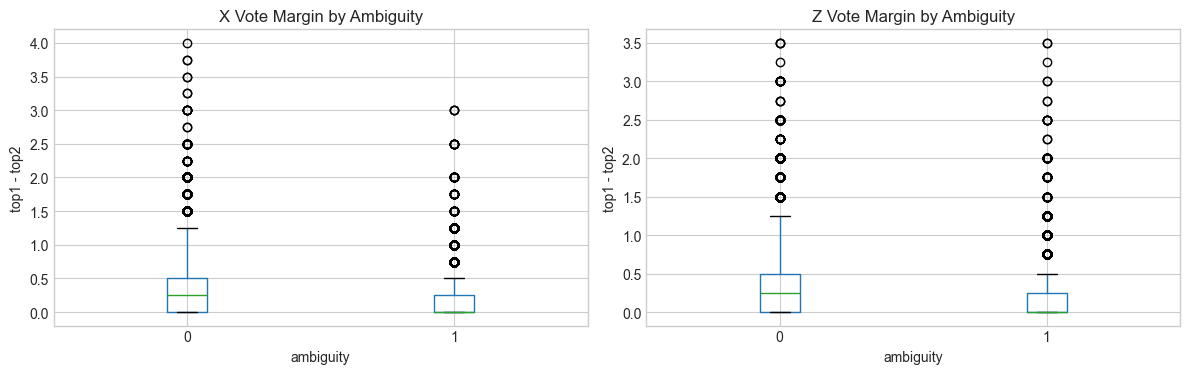

In [5]:
ambiguity = data['ambiguity']
x_votes = data['x_vote_maps']
z_votes = data['z_vote_maps']

def top_margin(votes):
    sorted_votes = np.sort(votes, axis=1)[:, ::-1]
    top1 = sorted_votes[:, 0]
    top2 = sorted_votes[:, 1]
    return top1 - top2

analysis_df = pd.DataFrame({
    'ambiguity': ambiguity,
    'x_hamming': x_hamming,
    'z_hamming': z_hamming,
    'x_vote_margin': top_margin(x_votes),
    'z_vote_margin': top_margin(z_votes),
})

display(analysis_df.groupby('ambiguity')[['x_hamming', 'z_hamming', 'x_vote_margin', 'z_vote_margin']].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
analysis_df.boxplot(column='x_vote_margin', by='ambiguity', ax=axes[0])
axes[0].set_title('X Vote Margin by Ambiguity')
axes[0].set_xlabel('ambiguity')
axes[0].set_ylabel('top1 - top2')
analysis_df.boxplot(column='z_vote_margin', by='ambiguity', ax=axes[1])
axes[1].set_title('Z Vote Margin by Ambiguity')
axes[1].set_xlabel('ambiguity')
axes[1].set_ylabel('top1 - top2')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Training Results Comparison
run_summary에서 학습 결과를 로드하여 h16 vs h32 비교, 양자화 검증, logical error rate를 확인한다.

,path,hidden_dim,best_val_exact,test_exact,test_bit_acc,clear_exact,ambig_exact,qat_exact,qat_bit_acc
0,x,32,0.655333,0.703333,0.949815,0.722936,0.65122,0.705667,0.950000
1,z,32,0.631000,0.709333,0.954444,0.739090,0.63062,0.713000,0.954556


,path,baseline_LER,model_LER,shots
0,x_path,0.1081,0.5169,10000
1,z_path,0.1264,0.5054,10000


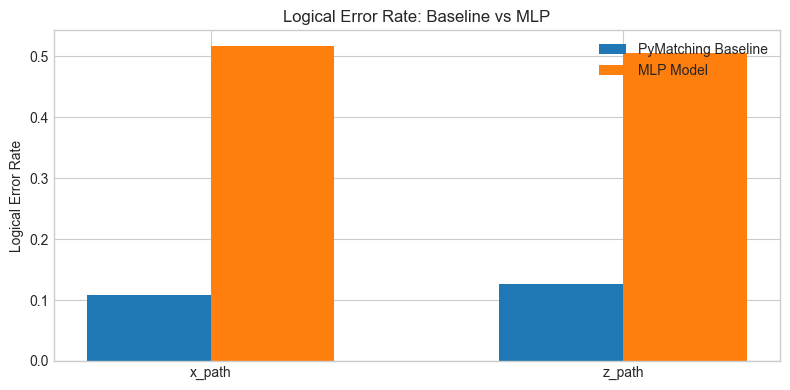

In [6]:
summary_path = workspace_root / 'artifacts' / 'reports' / 'run_summary.json'
summary = json.loads(summary_path.read_text(encoding='utf-8'))

rows = []
for path_key in ['x_path', 'z_path']:
    p = summary[path_key]
    rows.append({
        'path': p['path'],
        'hidden_dim': p['hidden_dim'],
        'best_val_exact': p['best_val_exact_match'],
        'test_exact': p['test_exact_match'],
        'test_bit_acc': p['test_bit_acc'],
        'clear_exact': p['test_ambiguity_clear']['exact_match'],
        'ambig_exact': p['test_ambiguity_ambiguous']['exact_match'],
        'qat_exact': p['quantized_test']['exact_match'],
        'qat_bit_acc': p['quantized_test']['bit_acc'],
    })

results_df = pd.DataFrame(rows)
display(results_df)

# Logical error rate
if 'logical_error_rate' in summary:
    ler = summary['logical_error_rate']
    ler_rows = []
    for path_key, vals in ler.items():
        ler_rows.append({
            'path': path_key,
            'baseline_LER': vals['baseline_logical_error_rate'],
            'model_LER': vals['model_logical_error_rate'],
            'shots': vals['num_shots'],
        })
    ler_df = pd.DataFrame(ler_rows)
    display(ler_df)

    fig, ax = plt.subplots(figsize=(8, 4))
    x_pos = np.arange(len(ler_df))
    ax.bar(x_pos - 0.15, ler_df['baseline_LER'], 0.3, label='PyMatching Baseline')
    ax.bar(x_pos + 0.15, ler_df['model_LER'], 0.3, label='MLP Model')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ler_df['path'])
    ax.set_ylabel('Logical Error Rate')
    ax.set_title('Logical Error Rate: Baseline vs MLP')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('logical_error_rate not available in run_summary')